In [36]:
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [37]:
df = pd.read_csv("modeling_ready_dataset.csv")

key_cols = ["season", "team"]
target_col = "made_playoffs"
feature_cols = [c for c in df.columns if c not in key_cols + [target_col]]

Creating 5 expanding window folds for temporal validation. 

Each fold trains on all prior seasons and tests on the next unseen year, ensuring the model never sees future data during training. We want to assess performance stability across multiple seasons

In [38]:
folds = []
for test_year in range(2021, 2026):
    train_mask = df["season"] < test_year
    test_mask = df["season"] == test_year

    fold = {
        "fold_num": test_year - 2020,
        "test_year": test_year,
        "train_seasons": sorted(df[train_mask]["season"].unique()),
        "X_train": df.loc[train_mask, feature_cols],
        "y_train": df.loc[train_mask, target_col],
        "X_test": df.loc[test_mask, feature_cols],
        "y_test": df.loc[test_mask, target_col],
    }
    folds.append(fold)

In [39]:
# Fold structure
fold_structure = []
for fold in folds:
    fold_structure.append({
        "Fold": fold["fold_num"],
        "Train Seasons": f"2018-{fold['train_seasons'][-1]}",
        "Train Rows": len(fold["X_train"]),
        "Train PO%": round(fold["y_train"].mean() * 100, 1),
        "Test Year": fold["test_year"],
        "Test Rows": len(fold["X_test"]),
        "Test PO%": round(fold["y_test"].mean() * 100, 1),
    })

display(pd.DataFrame(fold_structure).set_index("Fold"))

,Train Seasons,Train Rows,Train PO%,Test Year,Test Rows,Test PO%
Fold,,,,,,
1,2018-2020,96,39.6,2021,32,43.8
2,2018-2021,128,40.6,2022,32,43.8
3,2018-2022,160,41.2,2023,32,43.8
4,2018-2023,192,41.7,2024,32,43.8
5,2018-2024,224,42.0,2025,32,43.8


Verifying that no data leakage exists by confirming each fold's test year comes strictly after its latest training season. If any test data overlapped with training data, the assertion would stop the script and flag the problem

In [40]:
# Verify no data leakage

leakage_rows = []
for fold in folds:
    max_train = fold["train_seasons"][-1]
    assert fold["test_year"] > max_train, f"LEAKAGE in fold {fold['fold_num']}!"
    leakage_rows.append({
        "Fold": fold["fold_num"],
        "Train Through": max_train,
        "Test On": fold["test_year"],
        "Status": "OK"
    })
display(pd.DataFrame(leakage_rows).set_index("Fold"))

,Train Through,Test On,Status
Fold,,,
1,2020,2021,OK
2,2021,2022,OK
3,2022,2023,OK
4,2023,2024,OK
5,2024,2025,OK


### Baseline Benchmarks

Before building any real models, we establish baseline benchmarks to measure against. The evaluate_model helper function computes accuracy, precision, recall, F1, and AUC-ROC so we can reuse it consistently across all models. After creating the helper function, the first baseline always predicts non-playoff (0) for every team, representing the simplest possible approach. Any useful model must outperform this floor. Results are stored in all_results so we can compare all models side by side later.

In [41]:
# Helper function to compute all metrics
def evaluate_model(y_true, y_pred, y_prob=None):
    """Compute standard classification metrics."""
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_prob is not None:
        metrics["auc_roc"] = roc_auc_score(y_true, y_prob)
    return metrics

In [42]:
# Storage for all results
all_results = []

In [43]:
# Baseline 1: Naive Majority Class 
naive_rows = []
for fold in folds:
    y_pred = np.zeros(len(fold["y_test"]), dtype=int)
    metrics = evaluate_model(fold["y_test"], y_pred)
    metrics["auc_roc"] = 0.5

    naive_rows.append({
        "Fold": fold["fold_num"],
        "Test Year": fold["test_year"],
        "Acc": round(metrics["accuracy"], 3),
        "Prec": round(metrics["precision"], 3),
        "Recall": round(metrics["recall"], 3),
        "F1": round(metrics["f1"], 3),
    })

    all_results.append({
        "model": "Naive Majority",
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        **metrics
    })
display(pd.DataFrame(naive_rows).set_index("Fold"))

,Test Year,Acc,Prec,Recall,F1
Fold,,,,,
1,2021,0.562,0.0,0.0,0.0
2,2022,0.562,0.0,0.0,0.0
3,2023,0.562,0.0,0.0,0.0
4,2024,0.562,0.0,0.0,0.0
5,2025,0.562,0.0,0.0,0.0


Observing the output we see it predicts 56.2% accuracy just by saying no one will make the playoffs. Precision, recall, and F1 are all 0 because the model never predicts a single team as a playoff team. We gather that accuracy alone can be misleading because 56% sounds decent, but its useless when it cant identify a single playoff team. This baseline sets the absolute floor, so any model must beat the accuracy and also actually identify playoff teams.

**Second Baseline**

Our second baseline tests how far a single feature can go without any machine learning. Using score_pct_diff, which was our strongest predictor at r=0.704, we find the optimal threshold on training data that maximizes F1, then apply it to the test set.  If a team's scoring efficiency differential is above the threshold we want to predict playoff, otherwise, we predict non-playoffs.

In [44]:
# Baseline 2: Single-Feature Heuristic
best_feature = "score_pct_diff"
heuristic_rows = []

for fold in folds:
    train_vals = fold["X_train"][best_feature]
    train_labels = fold["y_train"]

    best_threshold = 0
    best_f1 = 0

    for threshold in np.arange(train_vals.min(), train_vals.max(), 0.5):
        preds = (train_vals >= threshold).astype(int)
        f1 = f1_score(train_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    y_pred = (fold["X_test"][best_feature] >= best_threshold).astype(int)

    train_min = train_vals.min()
    train_max = train_vals.max()
    y_prob = (fold["X_test"][best_feature] - train_min) / (train_max - train_min)
    y_prob = y_prob.clip(0, 1)

    metrics = evaluate_model(fold["y_test"], y_pred, y_prob)

    heuristic_rows.append({
        "Fold": fold["fold_num"],
        "Test Year": fold["test_year"],
        "Threshold": round(best_threshold, 1),
        "Acc": round(metrics["accuracy"], 3),
        "Prec": round(metrics["precision"], 3),
        "Recall": round(metrics["recall"], 3),
        "F1": round(metrics["f1"], 3),
        "AUC": round(metrics["auc_roc"], 3),
    })

    all_results.append({
        "model": "Heuristic (score_pct_diff)",
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        **metrics
    })
display(pd.DataFrame(heuristic_rows).set_index("Fold"))

,Test Year,Threshold,Acc,Prec,Recall,F1,AUC
Fold,,,,,,,
1,2021,-1.2,0.750,0.650,0.929,0.765,0.929
2,2022,-0.5,0.781,0.733,0.786,0.759,0.881
3,2023,-1.0,0.875,0.812,0.929,0.867,0.909
4,2024,-1.0,0.844,0.765,0.929,0.839,0.972
5,2025,-1.0,0.750,0.667,0.857,0.750,0.875


In [45]:
# Producing the averages 
baseline_avg = []
for model_name in ["Naive Majority", "Heuristic (score_pct_diff)"]:
    model_data = [r for r in all_results if r["model"] == model_name]
    baseline_avg.append({
        "Model": model_name,
        "Acc": round(np.mean([r["accuracy"] for r in model_data]), 3),
        "Prec": round(np.mean([r["precision"] for r in model_data]), 3),
        "Recall": round(np.mean([r["recall"] for r in model_data]), 3),
        "F1": round(np.mean([r["f1"] for r in model_data]), 3),
        "AUC": round(np.mean([r["auc_roc"] for r in model_data]), 3),
    })
display(pd.DataFrame(baseline_avg).set_index("Model"))

,Acc,Prec,Recall,F1,AUC
Model,,,,,
Naive Majority,0.562,0.000,0.000,0.000,0.500
Heuristic (score_pct_diff),0.800,0.725,0.886,0.796,0.913


Observing this output we can takeaway that a single feature with a simple threshold achieves 80% accuracy and .796 average F1 across all folds. A high recall average of 88.6% means it catches most playoff teams. While the precison score of 72.5% means it also flags non-playoff teams incorrectly. 

So, with our upcoming models of Logistic Regression, Random Forest and Gradient Boosting we need to beat the 0.796 F1 to justify their use over this simple one feature rule.

### Logistic Regression

We want to determine of the 64 features we still have if we should eliminate the weak features, or keep them all and how aggressively to regularize the data. Using the 2 penalties L1(Lasso), and L2(Ridge) will help determine feature results, while C will control how much regularization is applied.

In [46]:
param_grid_lr = {
    "C": [0.001, 0.01, 0.1, 1.0, 10.0], # controls how much the model is allowed to rely on the data 
    "penalty": ["l1", "l2"], # Lasso , Ridge
}

In [47]:
lr_models = []
lr_rows = []

for fold in folds:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(fold["X_train"])
    X_test_scaled = scaler.transform(fold["X_test"])

    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    lr = LogisticRegression(solver="saga", max_iter=5000, random_state=42)

    grid_search = GridSearchCV(
        estimator=lr,
        param_grid=param_grid_lr,
        cv=cv_inner,
        scoring="f1",
        n_jobs=-1,
        refit=True,
    )
    grid_search.fit(X_train_scaled, fold["y_train"])

    best_lr = grid_search.best_estimator_
    best_params = grid_search.best_params_

    y_pred = best_lr.predict(X_test_scaled)
    y_prob = best_lr.predict_proba(X_test_scaled)[:, 1]
    metrics = evaluate_model(fold["y_test"], y_pred, y_prob)

    lr_rows.append({
        "Fold": fold["fold_num"],
        "Test Year": fold["test_year"],
        "Best C": best_params["C"],
        "Penalty": best_params["penalty"],
        "Acc": round(metrics["accuracy"], 3),
        "Prec": round(metrics["precision"], 3),
        "Recall": round(metrics["recall"], 3),
        "F1": round(metrics["f1"], 3),
        "AUC": round(metrics["auc_roc"], 3),
    })

    all_results.append({
        "model": "Logistic Regression",
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        **metrics
    })

    lr_models.append({
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        "model": best_lr,
        "scaler": scaler,
        "best_params": best_params,
        "cv_best_score": grid_search.best_score_,
    })

display(pd.DataFrame(lr_rows).set_index("Fold"))

,Test Year,Best C,Penalty,Acc,Prec,Recall,F1,AUC
Fold,,,,,,,,
1,2021,1.0,l1,0.812,0.750,0.857,0.800,0.905
2,2022,0.1,l2,0.812,1.000,0.571,0.727,0.968
3,2023,10.0,l1,0.969,1.000,0.929,0.963,0.992
4,2024,10.0,l1,1.000,1.000,1.000,1.000,1.000
5,2025,10.0,l1,0.938,0.929,0.929,0.929,0.984


In [48]:
# Summary averages
lr_data = [r for r in all_results if r["model"] == "Logistic Regression"]
lr_avg = pd.DataFrame([{
    "Acc": round(np.mean([r["accuracy"] for r in lr_data]), 3),
    "Prec": round(np.mean([r["precision"] for r in lr_data]), 3),
    "Recall": round(np.mean([r["recall"] for r in lr_data]), 3),
    "F1": round(np.mean([r["f1"] for r in lr_data]), 3),
    "AUC": round(np.mean([r["auc_roc"] for r in lr_data]), 3),
}], index=["Logistic Regression"])
lr_avg

,Acc,Prec,Recall,F1,AUC
Logistic Regression,0.906,0.936,0.857,0.884,0.97


Observing this output we can notice already how much the accuracy is improved and the F1 values increased as well. L1 penalty was selected in 4 out of 5 folds, which confirms that feature elimination helps with this dataset. The C value increases as more training data becomes available, from 1.0 in Fold 1 to 10.0 in Folds 3 through 5, meaning the model uses less regularization when it has more data to learn from, which makes sense. Fold 4 in 2022, achieved perfect scores, while fild 2 in 2022 had the weakest. 

Most importantly we can takeaway that this beat both baselines. 

Now, to see which features matter most and whether they push toward or against playoff qualification.

In [49]:
# Top 15 features by coefficient magnitude (Fold 5)
final_lr = lr_models[-1]["model"]
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": final_lr.coef_[0],
    "Abs Coefficient": np.abs(final_lr.coef_[0])
}).sort_values("Abs Coefficient", ascending=False).head(15)
coef_df["Direction"] = coef_df["Coefficient"].apply(lambda x: "favors playoff" if x > 0 else "hurts playoff")
coef_df = coef_df[["Feature", "Coefficient", "Direction"]].reset_index(drop=True)
coef_df["Coefficient"] = coef_df["Coefficient"].round(4)
display(coef_df)

n_nonzero = (np.abs(final_lr.coef_[0]) > 0.001).sum()
print(f"Features with non-zero coefficients: {n_nonzero} / {len(feature_cols)}")
print(f"Features eliminated by regularization: {len(feature_cols) - n_nonzero}")

# Best parameters per fold
param_rows = []
for m in lr_models:
    param_rows.append({
        "Fold": m["fold"],
        "Test Year": m["test_year"],
        "C": m["best_params"]["C"],
        "Penalty": m["best_params"]["penalty"],
        "CV F1": round(m["cv_best_score"], 3),
    })
display(pd.DataFrame(param_rows).set_index("Fold"))

,Feature,Coefficient,Direction
0,def_adv_Air,8.8036,favors playoff
1,def_adv_YAC,5.6444,favors playoff
2,def_yds_allowed,-5.0437,hurts playoff
3,def_yds_per_play,-4.4453,hurts playoff
4,def_rush_Yds,2.8858,favors playoff
5,def_plays,-2.7133,hurts playoff
6,def_pass_ANY/A,-2.4101,hurts playoff
7,def_rush_Y/A,2.0597,favors playoff
8,def_rush_Att,1.2705,favors playoff
9,off_score_pct,1.1693,favors playoff


Features with non-zero coefficients: 41 / 65
Features eliminated by regularization: 24


,Test Year,C,Penalty,CV F1
Fold,,,,
1,2021,1.0,l1,0.921
2,2022,0.1,l2,0.871
3,2023,10.0,l1,0.894
4,2024,10.0,l1,0.943
5,2025,10.0,l1,0.958


Observing the above out put we have +/- numbers. The positive number means that as a feature's value increases, the model gives the team a higher probability of making the playoffs, while the opposite is true for a negative value. So, the larger the +/- number the the stronger that feature influences the prediction.

So, `off_score_pct` at `+1.1693` means that teams scoring on a higher percentage of theire drives are more likely to make the playoffs. While `def_yds_allowed` at `-5.0437` means that teams allowing more total yards are less likely to make the playoffs. 

L1 regularization eliminated 24 of the 65 features. So the model decided about 1/3 of them were not worth using. The parameters show L1 was preferred in 4 of 5 folds, and C increased from 1.0 to 10.0 as training data grew, meaning the model loosened its regularization when it had more data to support using more features. The steadily improving CV F1 scores. 0.921 to 0.958, confirm that more training data produced better models.

**Random Forest**

Random Forest is our second model, representing a flexible ensemble approach that can capture nonlinear relationships and feature interactions that Logistic Regression cannot. Unlike Logistic Regression, it does not require feature scaling and naturally handles correlated features. We use it to test whether more complex patterns exist in the data that a linear model misses, and to compare its feature importance rankings against the coefficient-based insights from Logistic Regression.

In [50]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [5, 10],
}
total_combos = len(param_grid_rf["n_estimators"]) * len(param_grid_rf["max_depth"]) * len(param_grid_rf["min_samples_split"])
print(total_combos)

12


Using the same structure as the Logistic Regression model but there is no scaling needed.

In [51]:
rf_models = []
rf_rows = []

for fold in folds:
    X_train = fold["X_train"]
    X_test = fold["X_test"]

    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid_rf,
        cv=cv_inner,
        scoring="f1",
        n_jobs=1,
        refit=True,
    )
    grid_search.fit(X_train, fold["y_train"])

    best_rf = grid_search.best_estimator_
    best_params = grid_search.best_params_

    y_pred = best_rf.predict(X_test)
    y_prob = best_rf.predict_proba(X_test)[:, 1]
    metrics = evaluate_model(fold["y_test"], y_pred, y_prob)

    depth_str = str(best_params["max_depth"]) if best_params["max_depth"] is not None else "None"
    rf_rows.append({
        "Fold": fold["fold_num"],
        "Test Year": fold["test_year"],
        "Trees": best_params["n_estimators"],
        "Max Depth": depth_str,
        "Min Split": best_params["min_samples_split"],
        "Acc": round(metrics["accuracy"], 3),
        "Prec": round(metrics["precision"], 3),
        "Recall": round(metrics["recall"], 3),
        "F1": round(metrics["f1"], 3),
        "AUC": round(metrics["auc_roc"], 3),
    })

    all_results.append({
        "model": "Random Forest",
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        **metrics
    })

    rf_models.append({
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        "model": best_rf,
        "best_params": best_params,
        "cv_best_score": grid_search.best_score_,
    })

display(pd.DataFrame(rf_rows).set_index("Fold"))

,Test Year,Trees,Max Depth,Min Split,Acc,Prec,Recall,F1,AUC
Fold,,,,,,,,,
1,2021,100,5,5,0.750,0.688,0.786,0.733,0.869
2,2022,200,5,10,0.781,0.889,0.571,0.696,0.933
3,2023,100,5,10,0.812,0.900,0.643,0.750,0.956
4,2024,200,5,10,0.906,0.923,0.857,0.889,0.948
5,2025,200,10,5,0.844,0.800,0.857,0.828,0.885


In [52]:
# Summary averages

rf_data = [r for r in all_results if r["model"] == "Random Forest"]
rf_avg = pd.DataFrame([{
    "Acc": round(np.mean([r["accuracy"] for r in rf_data]), 3),
    "Prec": round(np.mean([r["precision"] for r in rf_data]), 3),
    "Recall": round(np.mean([r["recall"] for r in rf_data]), 3),
    "F1": round(np.mean([r["f1"] for r in rf_data]), 3),
    "AUC": round(np.mean([r["auc_roc"] for r in rf_data]), 3),
}], index=["Random Forest"])
rf_avg

,Acc,Prec,Recall,F1,AUC
Random Forest,0.819,0.84,0.743,0.779,0.918


Observing the outputs from both code block above, we see it achieves decent performance around 82% accuracy and a F1 avg of 0.779. Comparing it to the LR we notice it underperforms.

In [18]:
# Top 15 features by importance 

final_rf = rf_models[-1]["model"]
rf_imp_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": final_rf.feature_importances_,
}).sort_values("Importance", ascending=False)

cumulative = 0
imp_rows = []
for _, row in rf_imp_df.head(15).iterrows():
    cumulative += row["Importance"]
    imp_rows.append({
        "Feature": row["Feature"],
        "Importance": round(row["Importance"], 4),
        "Cumulative %": round(cumulative * 100, 1),
    })
display(pd.DataFrame(imp_rows))

,Feature,Importance,Cumulative %
0,score_pct_diff,0.1269,12.7
1,pass_eff_diff,0.0910,21.8
2,off_pts,0.0642,28.2
3,off_score_pct,0.0514,33.4
4,off_pass_Rate,0.0356,36.9
5,def_pa,0.0354,40.5
6,off_exp,0.0326,43.7
7,turnover_margin,0.0317,46.9
8,to_rate_diff,0.0303,49.9
9,off_pass_ANY/A,0.0292,52.8


In [53]:
# Best parameters per fold

rf_param_rows = []
for m in rf_models:
    depth_str = str(m["best_params"]["max_depth"]) if m["best_params"]["max_depth"] is not None else "None"
    rf_param_rows.append({
        "Fold": m["fold"],
        "Test Year": m["test_year"],
        "Trees": m["best_params"]["n_estimators"],
        "Max Depth": depth_str,
        "Min Split": m["best_params"]["min_samples_split"],
        "CV F1": round(m["cv_best_score"], 3),
    })
display(pd.DataFrame(rf_param_rows).set_index("Fold"))

,Test Year,Trees,Max Depth,Min Split,CV F1
Fold,,,,,
1,2021,100,5,5,0.876
2,2022,200,5,10,0.820
3,2023,100,5,10,0.805
4,2024,200,5,10,0.803
5,2025,200,10,5,0.839


With the top 15 features we can see that they account for almost 63% of the total importance, while the remaining feautres account for just about 35%.

Observing the code blocks we can see that `score_pct_diff` leads at 12.7%, followed by `pass_eff_diff` at 9.1%. The top 15 features account for 62.4% of total importance, meaning the remaining 49 features collectively contribute less than 38%.

The best parameters per fold show that a max_depth of 5 was shosen 4/5 times, confirming shallow trees work best. Another thing to note are the F1 scores being lower than the LR model meaning LR is outperforming random forest.

**Gradient Boosting**

Our 3rd model is Gradient Boosting, representing the performance maximizing approach. We plan on using it to establish a performance ceilng and determine whether this added performance captures patterns missed by the other models.

Following a similar approach as the other 2 models.

In [54]:
param_grid_gb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
}

total_combos = len(param_grid_gb["n_estimators"]) * len(param_grid_gb["max_depth"]) * len(param_grid_gb["learning_rate"]) * len(param_grid_gb["subsample"])
print(total_combos)

16


In [55]:
gb_models = []
gb_rows = []

for fold in folds:
    X_train = fold["X_train"]
    X_test = fold["X_test"]

    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        param_grid_gb,
        cv=cv_inner,
        scoring="f1",
        n_jobs=-1,
        refit=True,
    )
    grid_search.fit(X_train, fold["y_train"])

    best_gb = grid_search.best_estimator_
    best_params = grid_search.best_params_

    y_pred = best_gb.predict(X_test)
    y_prob = best_gb.predict_proba(X_test)[:, 1]
    metrics = evaluate_model(fold["y_test"], y_pred, y_prob)

    gb_rows.append({
        "Fold": fold["fold_num"],
        "Test Year": fold["test_year"],
        "LR": best_params["learning_rate"],
        "Max Depth": best_params["max_depth"],
        "Trees": best_params["n_estimators"],
        "Subsample": best_params["subsample"],
        "Acc": round(metrics["accuracy"], 3),
        "Prec": round(metrics["precision"], 3),
        "Recall": round(metrics["recall"], 3),
        "F1": round(metrics["f1"], 3),
        "AUC": round(metrics["auc_roc"], 3),
    })

    all_results.append({
        "model": "Gradient Boosting",
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        **metrics
    })

    gb_models.append({
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        "model": best_gb,
        "best_params": best_params,
        "cv_best_score": grid_search.best_score_,
    })

print("\n--- Gradient Boosting Per-Fold Results ---")
display(pd.DataFrame(gb_rows).set_index("Fold"))


--- Gradient Boosting Per-Fold Results ---


,Test Year,LR,Max Depth,Trees,Subsample,Acc,Prec,Recall,F1,AUC
Fold,,,,,,,,,,
1,2021,0.10,3,100,0.8,0.844,0.846,0.786,0.815,0.873
2,2022,0.01,3,200,0.8,0.812,1.000,0.571,0.727,0.925
3,2023,0.10,3,200,0.8,0.875,0.812,0.929,0.867,0.921
4,2024,0.10,3,200,1.0,0.906,0.923,0.857,0.889,0.968
5,2025,0.10,3,100,0.8,0.844,0.800,0.857,0.828,0.889


In [56]:
# Summary averages

gb_data = [r for r in all_results if r["model"] == "Gradient Boosting"]
gb_avg = pd.DataFrame([{
    "Acc": round(np.mean([r["accuracy"] for r in gb_data]), 3),
    "Prec": round(np.mean([r["precision"] for r in gb_data]), 3),
    "Recall": round(np.mean([r["recall"] for r in gb_data]), 3),
    "F1": round(np.mean([r["f1"] for r in gb_data]), 3),
    "AUC": round(np.mean([r["auc_roc"] for r in gb_data]), 3),
}], index=["Gradient Boosting"])
gb_avg

,Acc,Prec,Recall,F1,AUC
Gradient Boosting,0.856,0.876,0.8,0.825,0.915


Observing the GB performace, we can see it performs solidly around 85.6% accuracy and with a F1 average of 0.825. It sits between Random Forest (0.779 F1) and Logistic Regression (0.884 F1). It's better than Random Forest but still can't match the other. 

In [58]:
# Top 15 features by importance

final_gb = gb_models[-1]["model"]
gb_imp_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": final_gb.feature_importances_,
}).sort_values("Importance", ascending=False)

cumulative = 0
gb_imp_rows = []
for _, row in gb_imp_df.head(15).iterrows():
    cumulative += row["Importance"]
    gb_imp_rows.append({
        "Feature": row["Feature"],
        "Importance": round(row["Importance"], 4),
        "Cumulative %": round(cumulative * 100, 1),
    })
display(pd.DataFrame(gb_imp_rows))

print(f"Top 15 account for {cumulative*100:.1f}% of total importance")
print(f"Remaining {len(feature_cols) - 15} features account for {(1-cumulative)*100:.1f}%")

# Best parameters per fold

gb_param_rows = []
for m in gb_models:
    gb_param_rows.append({
        "Fold": m["fold"],
        "Test Year": m["test_year"],
        "Learning Rate": m["best_params"]["learning_rate"],
        "Max Depth": m["best_params"]["max_depth"],
        "Trees": m["best_params"]["n_estimators"],
        "Subsample": m["best_params"]["subsample"],
        "CV F1": round(m["cv_best_score"], 3),
    })
display(pd.DataFrame(gb_param_rows).set_index("Fold"))

,Feature,Importance,Cumulative %
0,score_pct_diff,0.4696,47.0
1,def_adv_Air,0.0678,53.7
2,pass_eff_diff,0.0518,58.9
3,def_adv_YAC,0.0326,62.2
4,off_turnover_pct,0.0219,64.4
5,def_pa,0.0190,66.3
6,ypp_diff,0.0189,68.2
7,off_pts,0.0188,70.0
8,off_rush_TD,0.0168,71.7
9,def_pass_Rate,0.0148,73.2


Top 15 account for 80.1% of total importance
Remaining 50 features account for 19.9%


,Test Year,Learning Rate,Max Depth,Trees,Subsample,CV F1
Fold,,,,,,
1,2021,0.10,3,100,0.8,0.852
2,2022,0.01,3,200,0.8,0.823
3,2023,0.10,3,200,0.8,0.800
4,2024,0.10,3,200,1.0,0.804
5,2025,0.10,3,100,0.8,0.845


Observing the above output we see gradient boosting concentrates importance much more heavily than random forest. `score_pct_diff` alone account for 47% of total importance. The top 15 features account for about 80% of importance and the remaining features less than 20%.

**Cross Model Comparison**

In [24]:
import matplotlib.pyplot as plt

In [59]:
final_results = pd.DataFrame(all_results)

# Average Performance Across 5 Expanding Window Folds

models = ["Naive Majority", "Heuristic (score_pct_diff)", "Logistic Regression", "Random Forest", "Gradient Boosting"]
metrics = ["accuracy", "precision", "recall", "f1", "auc_roc"]

avg_table = []
for model_name in models:
    model_data = final_results[final_results["model"] == model_name]
    row = {"Model": model_name}
    for m in metrics:
        row[m] = round(model_data[m].mean(), 3)
    avg_table.append(row)

display(pd.DataFrame(avg_table).set_index("Model"))

,accuracy,precision,recall,f1,auc_roc
Model,,,,,
Naive Majority,0.562,0.000,0.000,0.000,0.500
Heuristic (score_pct_diff),0.800,0.725,0.886,0.796,0.913
Logistic Regression,0.906,0.936,0.857,0.884,0.970
Random Forest,0.819,0.840,0.743,0.779,0.918
Gradient Boosting,0.856,0.876,0.800,0.825,0.915


In [60]:
# F1 Score by Fold (Stability Comparison)
fold_models = ["Heuristic (score_pct_diff)", "Logistic Regression", "Random Forest", "Gradient Boosting"]

fold_table = []
for model_name in fold_models:
    model_data = final_results[final_results["model"] == model_name].sort_values("test_year")
    f1_scores = model_data["f1"].values
    row = {"Model": model_name}
    for i, year in enumerate([2021, 2022, 2023, 2024, 2025]):
        row[str(year)] = round(f1_scores[i], 3)
    row["Avg"] = round(f1_scores.mean(), 3)
    row["Std"] = round(f1_scores.std(), 3)
    fold_table.append(row)

display(pd.DataFrame(fold_table).set_index("Model"))

,2021,2022,2023,2024,2025,Avg,Std
Model,,,,,,,
Heuristic (score_pct_diff),0.765,0.759,0.867,0.839,0.750,0.796,0.048
Logistic Regression,0.800,0.727,0.963,1.000,0.929,0.884,0.103
Random Forest,0.733,0.696,0.750,0.889,0.828,0.779,0.070
Gradient Boosting,0.815,0.727,0.867,0.889,0.828,0.825,0.056


In [61]:
# Improvement Over Baselines
naive_f1 = final_results[final_results["model"] == "Naive Majority"]["f1"].mean()
heuristic_f1 = final_results[final_results["model"] == "Heuristic (score_pct_diff)"]["f1"].mean()

imp_table = []
for model_name in ["Logistic Regression", "Random Forest", "Gradient Boosting"]:
    model_f1 = final_results[final_results["model"] == model_name]["f1"].mean()
    imp_table.append({
        "Model": model_name,
        "vs Naive": round(model_f1 - naive_f1, 3),
        "vs Heuristic": round(model_f1 - heuristic_f1, 3),
    })
display(pd.DataFrame(imp_table).set_index("Model"))

,vs Naive,vs Heuristic
Model,,
Logistic Regression,0.884,0.088
Random Forest,0.779,-0.017
Gradient Boosting,0.825,0.029


Across all five expanding window folds, Logistic Regression is the clear winner with the highest average performance on every metric. Gradient Boosting takes second with an F1 of 0.825 and is the most stable year to year, while Random Forest trails in third with F1 = 0.779 and actually performs slightly worse than the simple one-feature heuristic baseline. Only Logistic Regression provides a meaningful improvement over the heuristic of 0.088 F1, while the tree-based models add complexity without delivering proportional gains. The 2022 season was the hardest to predict across all models, and 2024 was the easiest. These results confirm that NFL playoff prediction is fundamentally a linear problem well-suited to interpretable modeling, directly supporting the project's decision-support objectives from Assignment 1.

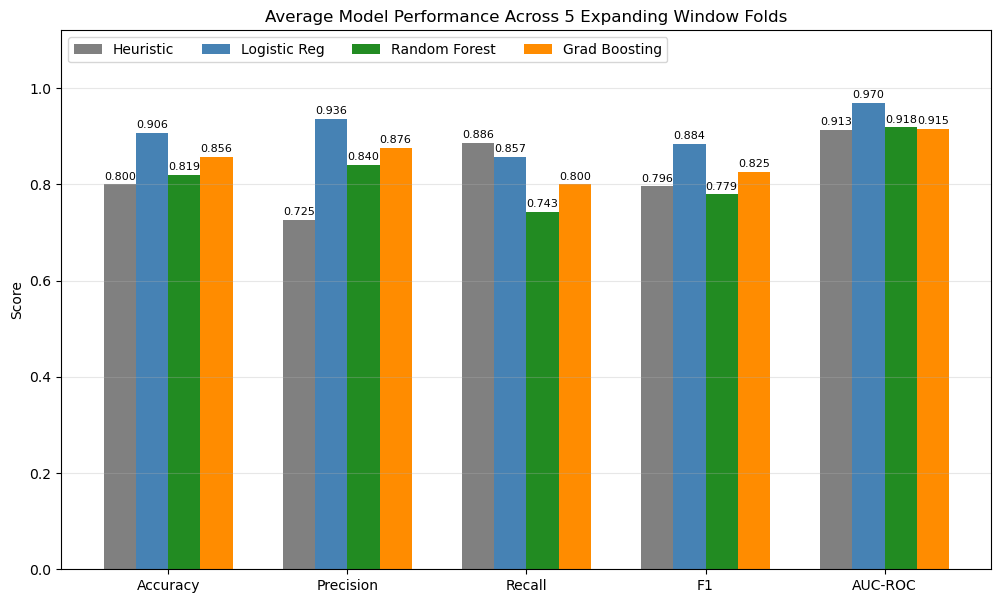

In [62]:
# MODEL PERFORMANCE COMPARISON

models = ["Heuristic", "Logistic Reg", "Random Forest", "Grad Boosting"]
model_keys = ["Heuristic (score_pct_diff)", "Logistic Regression", "Random Forest", "Gradient Boosting"]
metrics = ["accuracy", "precision", "recall", "f1", "auc_roc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
colors = ["gray", "steelblue", "forestgreen", "darkorange"]

# Calculate averages for each model
averages = {}
for key, name in zip(model_keys, models):
    model_data = [r for r in all_results if r["model"] == key]
    averages[name] = [np.mean([r[m] for r in model_data]) for m in metrics]

# Create grouped bars
x = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 7))

for i, (model, color) in enumerate(zip(models, colors)):
    bars = ax.bar(x + i * width, averages[model], width, label=model, color=color)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.3f}",
                ha="center", fontsize=8)

ax.set_ylabel("Score")
ax.set_title("Average Model Performance Across 5 Expanding Window Folds")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.12)
ax.legend(loc="upper left", ncol=4)
ax.grid(True, alpha=0.3, axis="y")
plt.show()

We want to plot model results and begin extracting the 2025 test set predictions from each model's Fold 5, so we can generate diagnostic plots comparing how all three models performed on the most recent season. 2025 had the most training data so it is the most stable version of each model.

In [63]:
# Get Fold 5 data for plotting
X_test_2025 = df.loc[df["season"] == 2025, feature_cols]
y_test_2025 = df.loc[df["season"] == 2025, target_col]

# Get predictions from stored Fold 5 models
scaler_5 = lr_models[-1]["scaler"]
lr_pred = lr_models[-1]["model"].predict(scaler_5.transform(X_test_2025))
rf_pred = rf_models[-1]["model"].predict(X_test_2025)
gb_pred = gb_models[-1]["model"].predict(X_test_2025)

In [64]:
import seaborn as sns

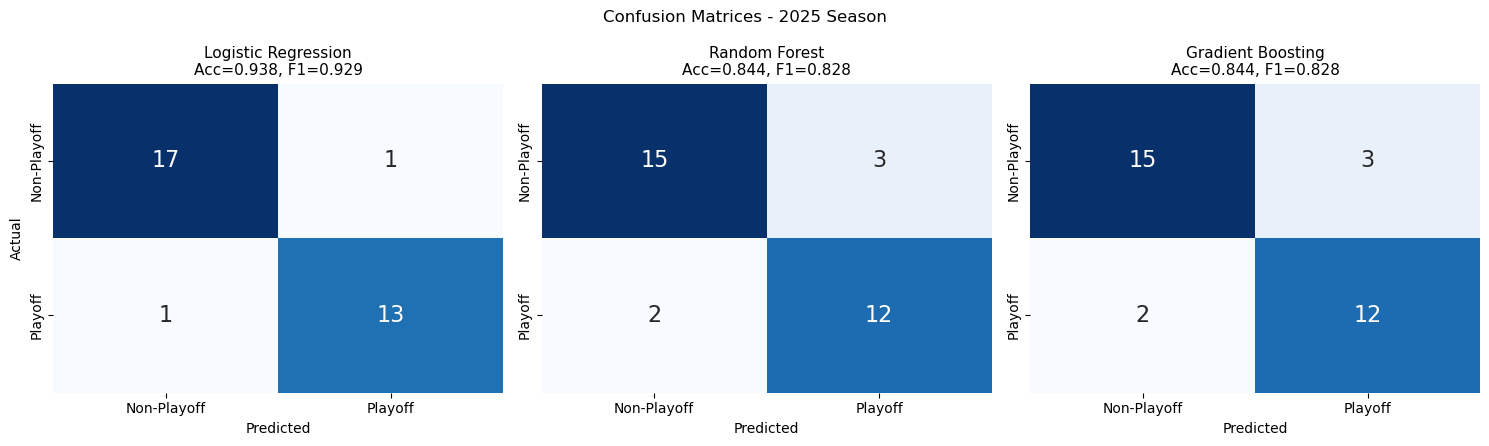

In [65]:
# CONFUSION MATRICES
from sklearn.metrics import confusion_matrix

names = ["Logistic Regression", "Random Forest", "Gradient Boosting"]
predictions = [lr_pred, rf_pred, gb_pred]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i in range(3):
    cm = confusion_matrix(y_test_2025, predictions[i])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Non-Playoff", "Playoff"],
                yticklabels=["Non-Playoff", "Playoff"],
                cbar=False, annot_kws={"size": 16})

    acc = accuracy_score(y_test_2025, predictions[i])
    f1 = f1_score(y_test_2025, predictions[i])
    axes[i].set_title(f"{names[i]}\nAcc={acc:.3f}, F1={f1:.3f}", fontsize=11)
    axes[i].set_xlabel("Predicted")
    if i == 0:
        axes[i].set_ylabel("Actual")

fig.suptitle("Confusion Matrices - 2025 Season")
plt.tight_layout()
plt.show()

Plot 1 shows exactly how each model classified the 32 teams in the 2025 season. Each cell tells you how many non-playoff teams were correctly identified (top-left), how many non-playoff teams were incorrectly predicted as playoff (top-right), how many playoff teams were missed (bottom-left), and how many playoff teams were correctly identified (bottom-right)
Logistic Regression made only 2 errors on the entire 2025 season. 1 non-playoff team incorrectly predicted as playoff, and 1 playoff team missed. Random Forest and Gradient Boosting made identical errors. 3 non-playoff teams incorrectly flagged and 2 playoff teams missed (5 total errors each). This visually confirms why Logistic Regression has the highest accuracy, 0.938, and F1 of 0.929 on the final holdout.

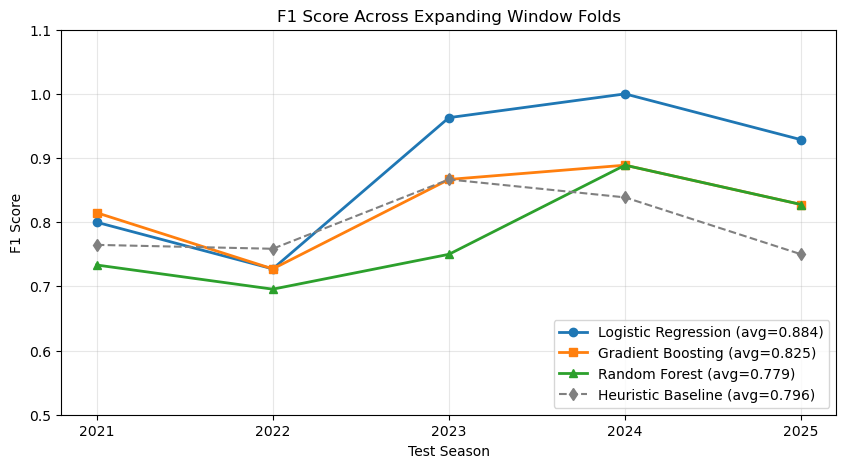

In [66]:
# F1 SCORE ACROSS FOLDS

fold_years = [2021, 2022, 2023, 2024, 2025]

# Pull F1 scores from stored results
f1_lr = [r["f1"] for r in all_results if r["model"] == "Logistic Regression"]
f1_rf = [r["f1"] for r in all_results if r["model"] == "Random Forest"]
f1_gb = [r["f1"] for r in all_results if r["model"] == "Gradient Boosting"]
f1_heuristic = [r["f1"] for r in all_results if r["model"] == "Heuristic (score_pct_diff)"]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(fold_years, f1_lr, "o-", label=f"Logistic Regression (avg={np.mean(f1_lr):.3f})", linewidth=2)
ax.plot(fold_years, f1_gb, "s-", label=f"Gradient Boosting (avg={np.mean(f1_gb):.3f})", linewidth=2)
ax.plot(fold_years, f1_rf, "^-", label=f"Random Forest (avg={np.mean(f1_rf):.3f})", linewidth=2)
ax.plot(fold_years, f1_heuristic, "d--", label=f"Heuristic Baseline (avg={np.mean(f1_heuristic):.3f})", color="gray")

ax.set_xlabel("Test Season")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score Across Expanding Window Folds")
ax.set_xticks(fold_years)
ax.set_ylim(0.5, 1.1)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.show()

Logistic Regression's blue line sits clearly above the others from 2023 onward. It is pulling away as the training data grows. All models dip in 2022 and all improve with more training data. The heuristic baseline tracks closely with Random Forest and Gradient Boosting in early folds showing us that those complex models barely beat a simple rule. The widening gap between Logistic Regression and everything else from 2023 to 2025 is the strongest visual evidence for model selection.

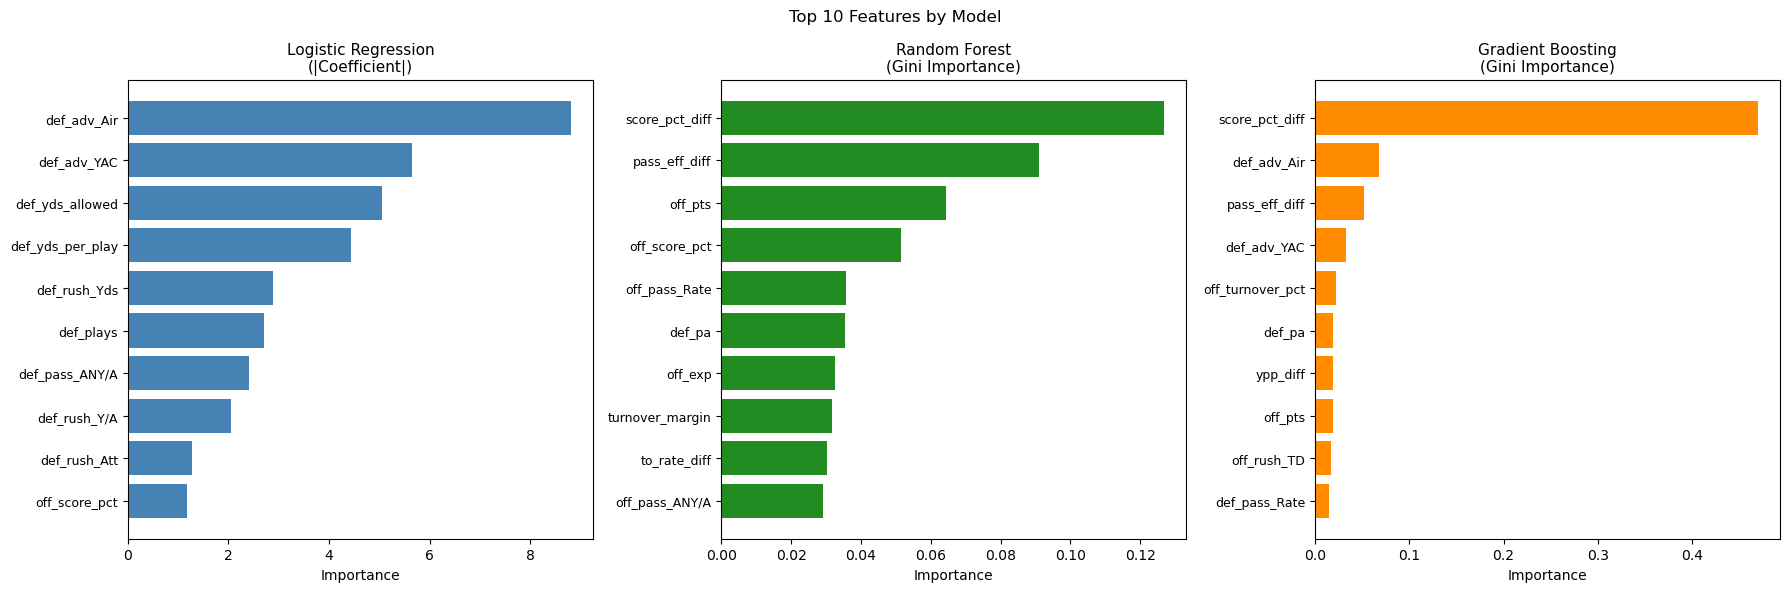

In [67]:
#FEATURE IMPORTANCE COMPARISON

# Get Fold 5 models
lr_model_5 = lr_models[-1]["model"]
rf_model_5 = rf_models[-1]["model"]
gb_model_5 = gb_models[-1]["model"]

# Get importance values for each model
lr_imp = pd.DataFrame({"feature": feature_cols, "importance": np.abs(lr_model_5.coef_[0])})
rf_imp = pd.DataFrame({"feature": feature_cols, "importance": rf_model_5.feature_importances_})
gb_imp = pd.DataFrame({"feature": feature_cols, "importance": gb_model_5.feature_importances_})

# Sort and keep top 10 for each
lr_imp = lr_imp.sort_values("importance", ascending=False).head(10)
rf_imp = rf_imp.sort_values("importance", ascending=False).head(10)
gb_imp = gb_imp.sort_values("importance", ascending=False).head(10)

# Plot side by side
names = ["Logistic Regression\n(|Coefficient|)", "Random Forest\n(Gini Importance)", "Gradient Boosting\n(Gini Importance)"]
importances = [lr_imp, rf_imp, gb_imp]
colors = ["steelblue", "forestgreen", "darkorange"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i in range(3):
    axes[i].barh(range(10), importances[i]["importance"].values, color=colors[i])
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels(importances[i]["feature"].values, fontsize=9)
    axes[i].invert_yaxis()
    axes[i].set_title(names[i], fontsize=11)
    axes[i].set_xlabel("Importance")

fig.suptitle("Top 10 Features by Model")
plt.tight_layout()
plt.show()

Plot 3 reveals an interesting finding. Logistic Regression relies heavily on defensive metrics, def_adv_Air, def_adv_YAC, and def_yds_allowed, which dominated its top features. Random Forest and Gradient Boosting both put score_pct_diff as their top feature by a large margin. All three models include defensive advanced metrics in their top 10, validating the decision to retain those features. The cross-model agreement on the importance of engineered differentials and defensive advanced stats confirms these features capture genuine signal, not noise.

In [68]:
# ROC CURVES
from sklearn.metrics import roc_curve, auc

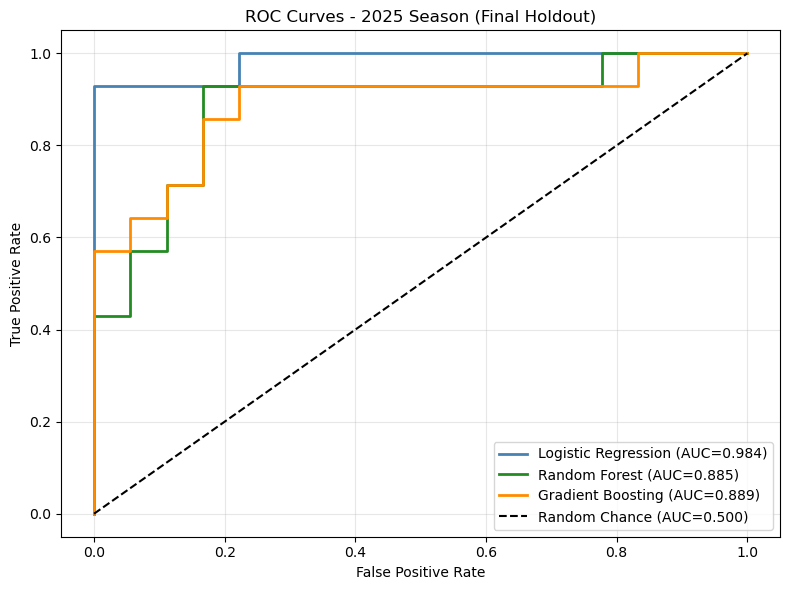

In [69]:
# Get probability predictions from stored Fold 5 models
scaler_5 = lr_models[-1]["scaler"]
lr_prob = lr_models[-1]["model"].predict_proba(scaler_5.transform(X_test_2025))[:, 1]
rf_prob = rf_models[-1]["model"].predict_proba(X_test_2025)[:, 1]
gb_prob = gb_models[-1]["model"].predict_proba(X_test_2025)[:, 1]

names = ["Logistic Regression", "Random Forest", "Gradient Boosting"]
probs = [lr_prob, rf_prob, gb_prob]
colors = ["steelblue", "forestgreen", "darkorange"]

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_2025, probs[i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], linewidth=2, label=f"{names[i]} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Random Chance (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - 2025 Season (Final Holdout)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Observing the visualization of the ROC 'curves' above we can notice the LR hugging the top-left corner the most, meaning it does the best job of separating playoff from non-playoff teams across all probability thresholds, while the other 2 models RF and GB, perform similarly to each other and noticeably worse than the LR model. With all 3 being above the dashed line, it gives us the insight into the models having real predictive power.

In [70]:
# See which 2025 teams the model got right and wrong
teams_2025 = df[df["season"] == 2025].copy()
X_2025 = lr_models[-1]["scaler"].transform(teams_2025[feature_cols])
teams_2025["Probability"] = lr_models[-1]["model"].predict_proba(X_2025)[:, 1]
teams_2025["Predicted"] = lr_models[-1]["model"].predict(X_2025)

result = teams_2025[["team", "made_playoffs", "Predicted", "Probability"]].copy()
result.columns = ["Team", "Actually Made", "Predicted", "Probability"]
result["Correct"] = result["Actually Made"] == result["Predicted"]
result = result.sort_values("Probability", ascending=False).reset_index(drop=True)
result.index = range(1, 33)
display(result)

,Team,Actually Made,Predicted,Probability,Correct
1,Los Angeles Rams,1,1,9.999991e-01,True
2,Houston Texans,1,1,9.999980e-01,True
3,Buffalo Bills,1,1,9.999911e-01,True
4,New England Patriots,1,1,9.999361e-01,True
5,Jacksonville Jaguars,1,1,9.999343e-01,True
6,Chicago Bears,1,1,9.997976e-01,True
7,Denver Broncos,1,1,9.989720e-01,True
8,Green Bay Packers,1,1,9.976453e-01,True
9,Los Angeles Chargers,1,1,9.972119e-01,True
10,San Francisco 49ers,1,1,9.953641e-01,True


In [72]:
# Predict playoffs for 2023, 2024, and 2025 using Fold 3, 4, and 5 models

for fold_idx, test_year in zip([2, 3, 4], [2023, 2024, 2025]):
    model_info = lr_models[fold_idx]
    teams = df[df["season"] == test_year].copy()
    X_test = model_info["scaler"].transform(teams[feature_cols])
    teams["Probability"] = model_info["model"].predict_proba(X_test)[:, 1]
    teams["Predicted"] = model_info["model"].predict(X_test)
    teams["Correct"] = teams["made_playoffs"] == teams["Predicted"]
    
    correct = teams["Correct"].sum()
    total = len(teams)
    missed = teams[teams["Correct"] == False]
    
    print(f" {test_year} Season ({correct}/{total} correct)")
    
    result = teams[["team", "made_playoffs", "Predicted", "Probability", "Correct"]].copy()
    result.columns = ["Team", "Actually Made", "Predicted", "Probability", "Correct"]
    result = result.sort_values("Probability", ascending=False).reset_index(drop=True)
    result.index = range(1, 33)
    display(result)

 2023 Season (31/32 correct)


,Team,Actually Made,Predicted,Probability,Correct
1,San Francisco 49ers,1,1,1.000000,True
2,Baltimore Ravens,1,1,1.000000,True
3,Kansas City Chiefs,1,1,1.000000,True
4,Detroit Lions,1,1,1.000000,True
5,Dallas Cowboys,1,1,0.999999,True
6,Tampa Bay Buccaneers,1,1,0.999990,True
7,Houston Texans,1,1,0.999890,True
8,Buffalo Bills,1,1,0.999857,True
9,Green Bay Packers,1,1,0.999662,True
10,Los Angeles Rams,1,1,0.999230,True


 2024 Season (32/32 correct)


,Team,Actually Made,Predicted,Probability,Correct
1,Philadelphia Eagles,1,1,1.000000e+00,True
2,Washington Commanders,1,1,1.000000e+00,True
3,Buffalo Bills,1,1,9.999999e-01,True
4,Kansas City Chiefs,1,1,9.999998e-01,True
5,Detroit Lions,1,1,9.999995e-01,True
6,Baltimore Ravens,1,1,9.999971e-01,True
7,Tampa Bay Buccaneers,1,1,9.999622e-01,True
8,Los Angeles Chargers,1,1,9.998663e-01,True
9,Minnesota Vikings,1,1,9.998159e-01,True
10,Denver Broncos,1,1,9.989987e-01,True


 2025 Season (30/32 correct)


,Team,Actually Made,Predicted,Probability,Correct
1,Los Angeles Rams,1,1,9.999991e-01,True
2,Houston Texans,1,1,9.999980e-01,True
3,Buffalo Bills,1,1,9.999911e-01,True
4,New England Patriots,1,1,9.999361e-01,True
5,Jacksonville Jaguars,1,1,9.999343e-01,True
6,Chicago Bears,1,1,9.997976e-01,True
7,Denver Broncos,1,1,9.989720e-01,True
8,Green Bay Packers,1,1,9.976453e-01,True
9,Los Angeles Chargers,1,1,9.972119e-01,True
10,San Francisco 49ers,1,1,9.953641e-01,True
